Dataset Shape: (20640, 8)

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

MODEL PERFORMANCE

Linear Regression
RMSE : 0.7456
R2 Score : 0.5758

Ridge Regression
RMSE : 0.7456
R2 Score : 0.5758

Decision Tree
RMSE : 0.7242
R2 Score : 0.5997

COMPARISON TABLE
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732

Best Model: Decision Tree


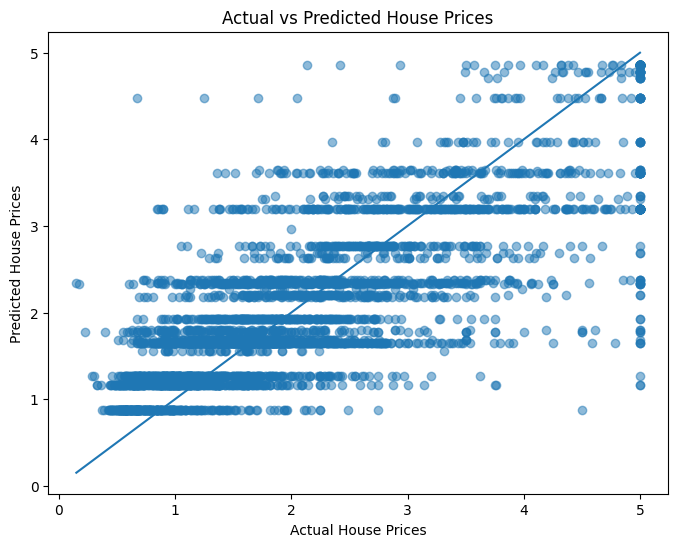


Graph saved as actual_vs_predicted.png
Results saved as model_comparison_results.csv

TASK 2 COMPLETED SUCCESSFULLY


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# STEP 1: LOAD DATASET
# ==========================================

housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("Dataset Shape:", X.shape)

print("\nFirst 5 Rows:")
print(X.head())

# ==========================================
# STEP 2: FEATURE SCALING
# ==========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature Scaling Completed")

# ==========================================
# STEP 3: TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split Completed")

# ==========================================
# STEP 4: DEFINE MODELS
# ==========================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

# ==========================================
# STEP 5: TRAIN & EVALUATE
# ==========================================

results = {}

print("\nMODEL PERFORMANCE")
print("=" * 50)

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

    print(f"\n{name}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2 Score : {r2:.4f}")

# ==========================================
# STEP 6: COMPARISON TABLE
# ==========================================

results_df = pd.DataFrame(results).T

print("\nCOMPARISON TABLE")
print(results_df)

# Save results table
results_df.to_csv("model_comparison_results.csv")

# ==========================================
# STEP 7: BEST MODEL
# ==========================================

best_model_name = results_df["R2 Score"].idxmax()

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

# ==========================================
# GRAPH 1
# ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_best, alpha=0.5)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)]
)

plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2
# RMSE COMPARISON
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df.index,
    results_df["RMSE"]
)

plt.title("RMSE Comparison of Models")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 3
# R2 SCORE COMPARISON
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df.index,
    results_df["R2 Score"]
)

plt.title("R² Score Comparison of Models")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 4
# COMBINED COMPARISON
# ==========================================

results_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

print("\nTask 2 Completed Successfully!")